
TRIAL 1: Initial = [-1.5         1.8        -2.35619449  0.2       ]
[Step 0/2000]  psi=3.3257e+00  phi=3.6051e+00
[Step 50/2000]  psi=1.1245e+01  phi=5.0677e+01
REACHED TARGET at step 81
Result: REACHED
Steps: 83

TRIAL 2: Initial = [1.35       1.65       3.14159265 0.5       ]
[Step 0/2000]  psi=1.4396e+01  phi=4.3352e+01
[Step 50/2000]  psi=8.6263e+00  phi=5.9177e+00
REACHED TARGET at step 75
Result: REACHED
Steps: 77

TRIAL 3: Initial = [0.   1.75 0.   1.  ]
[Step 0/2000]  psi=9.1299e+00  phi=1.6520e+01
REACHED TARGET at step 36
Result: REACHED
Steps: 38


C:\Users\nisha\AppData\Local\Temp\ipykernel_12488\1865487322.py:451: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X[0, 0], X[0, 1], s=50, c=BetterColor.orange3(), linewidth=0.3, zorder=20)
C:\Users\nisha\AppData\Local\Temp\ipykernel_12488\1865487322.py:452: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X[-1, 0], X[-1, 1], s=50, c=BetterColor.green0(), marker="x", linewidth=0.5, zorder=200)


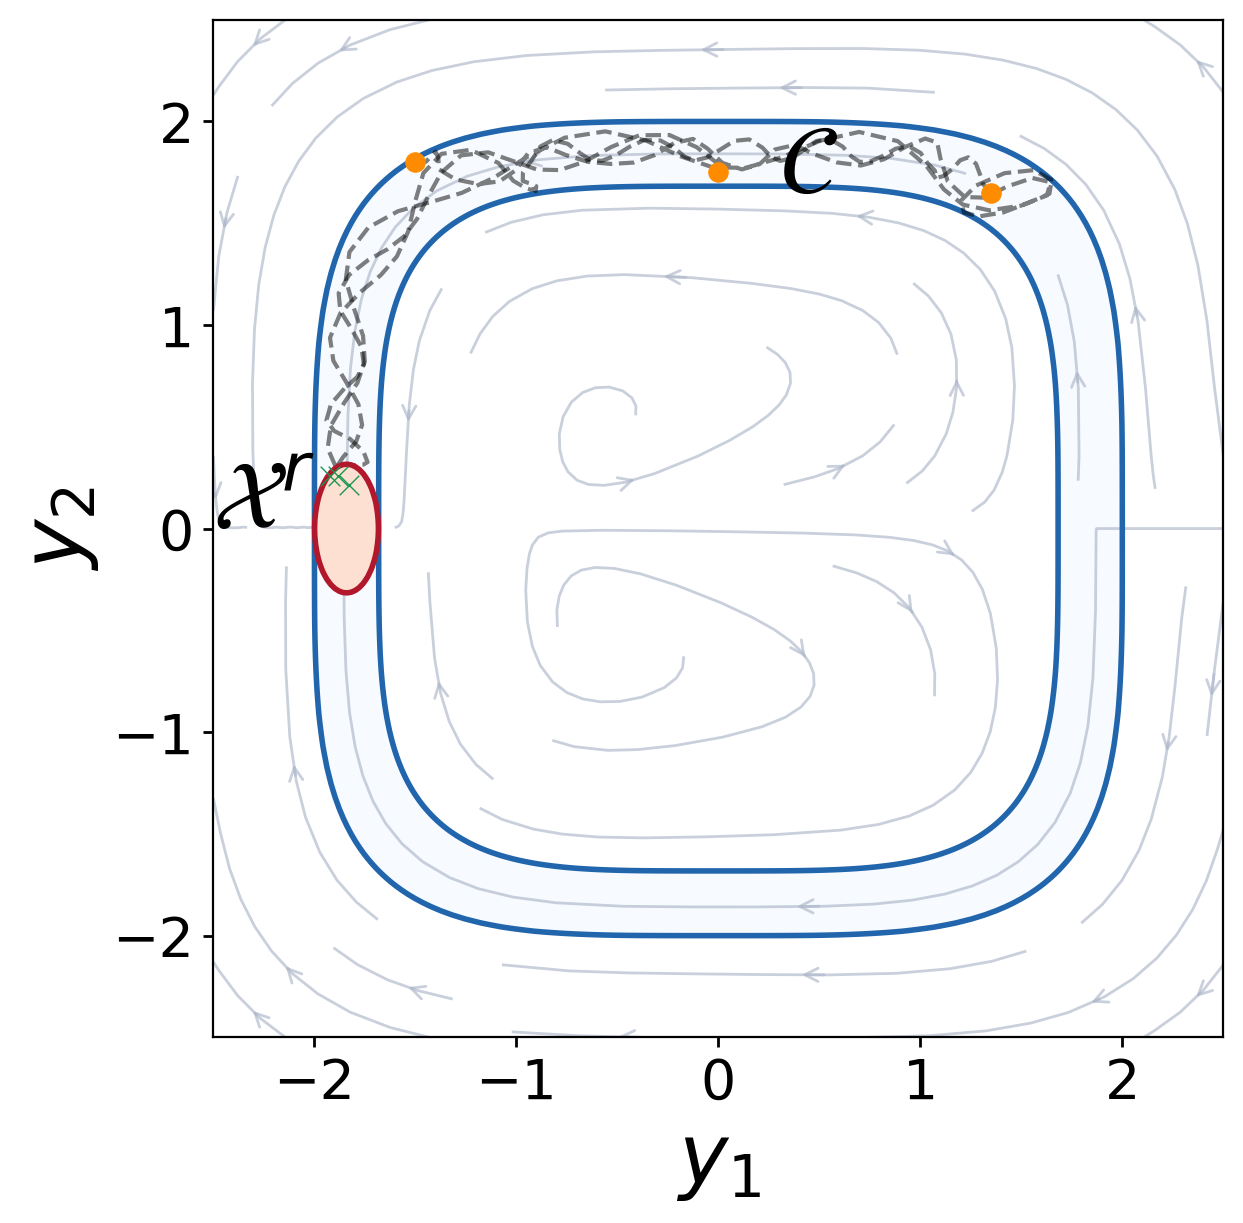

In [ ]:
"""
do-mpc implementation
"""

import math
import numpy as np
import casadi as ca
import sympy as sp
import matplotlib.pyplot as plt
import do_mpc
from do_mpc.model import Model
from do_mpc.controller import MPC
from k1_dubins_car_copy import k1_0, k1_1, y, val_lambda, val_delta

DT = 0.0004
HORIZON = 8
MU_1 = 4000.0
EPS_G_INV = 1e-6

Qy = 0.0
R_u = 0.0
ALPHA = 1.0

GOAL = np.array([-1.841, 0.0])

# IPOPT settings
IPOPT_MAX_CPU = 1.5
IPOPT_TOL = 1e-6

lam_val = float(val_lambda)
y0_s, y1_s = sp.symbols('y0 y1')

psi_sym = -(y0_s**4 + y1_s**4 - 16) * (y0_s**4 + y1_s**4 - 8)
phi_sym = ((y0_s + 1.841) / 0.5)**2 + (y1_s)**2 - 0.1

psi_np = sp.lambdify((y0_s, y1_s), psi_sym, 'numpy')
phi_np = sp.lambdify((y0_s, y1_s), phi_sym, 'numpy')

def sympy_poly_to_casadi_SX(sym_expr, sym_vars, cas_vars):
    poly = sp.Poly(sp.expand(sym_expr), *sym_vars)
    expr_val = ca.SX(0)
    for mon_exps, coeff in poly.as_dict().items():
        coeff_f = float(sp.N(coeff))
        term = ca.SX(coeff_f)
        for idx, e in enumerate(mon_exps):
            if e != 0:
                term = term * (cas_vars[idx] ** int(e))
        expr_val = expr_val + term
    return expr_val

def build_model():
    model = Model('discrete')

    # States
    y0 = model.set_variable('_x', 'y0')
    y1 = model.set_variable('_x', 'y1')
    th = model.set_variable('_x', 'theta')
    v = model.set_variable('_x', 'v')

    # Inputs
    u_th = model.set_variable('_u', 'u_theta')
    u_v = model.set_variable('_u', 'u_v')

    x = ca.vertcat(y0, y1, th, v)
    u = ca.vertcat(u_th, u_v)
    y_vec = ca.vertcat(y0, y1)

    # psi(y)
    psi_cas = sympy_poly_to_casadi_SX(psi_sym, (y0_s, y1_s), [y0, y1])
    model.set_expression('psi', psi_cas)

    # k1(y)
    k1_0_cas = sympy_poly_to_casadi_SX(k1_0, (y0_s, y1_s), [y0, y1])
    k1_1_cas = sympy_poly_to_casadi_SX(k1_1, (y0_s, y1_s), [y0, y1])
    k1 = ca.vertcat(k1_0_cas, k1_1_cas)

    # Lf h
    Lfh = ca.vertcat(v*ca.cos(th), v*ca.sin(th))

    # Dk1
    Dk1 = ca.jacobian(k1, y_vec)

    # G(x) - Tikhonov regularized inverse
    G = ca.vertcat(
        ca.horzcat(-v*ca.sin(th), ca.cos(th)),
        ca.horzcat(v*ca.cos(th), ca.sin(th))
    )
    GtG = G.T @ G + EPS_G_INV * ca.SX.eye(2)
    Ginv = ca.inv(GtG) @ G.T

    # Backstepping controller k(x)
    dpsi = ca.jacobian(psi_cas, y_vec).T
    rhs = MU_1*dpsi + Dk1@Lfh + (lam_val/2)*(Lfh - k1)
    k_full = Ginv @ rhs

    model.set_expression('k_full', k_full)

    # Psi certificate
    diff = Lfh - k1
    Psi = psi_cas - (1/(2*MU_1))*(diff.T@diff)
    model.set_expression('Psi', Psi)

    # Discrete RK4 dynamics
    def rk4(x, u):
        f = ca.vertcat(x[3]*ca.cos(x[2]), x[3]*ca.sin(x[2]), u[0], u[1])
        k1r = f
        k2r = ca.vertcat((x+0.5*DT*k1r)[3]*ca.cos((x+0.5*DT*k1r)[2]),
                         (x+0.5*DT*k1r)[3]*ca.sin((x+0.5*DT*k1r)[2]), u[0], u[1])
        k3r = ca.vertcat((x+0.5*DT*k2r)[3]*ca.cos((x+0.5*DT*k2r)[2]),
                         (x+0.5*DT*k2r)[3]*ca.sin((x+0.5*DT*k2r)[2]), u[0], u[1])
        k4r = ca.vertcat((x+DT*k3r)[3]*ca.cos((x+DT*k3r)[2]),
                         (x+DT*k3r)[3]*ca.sin((x+DT*k3r)[2]), u[0], u[1])
        return x + (DT/6)*(k1r+2*k2r+2*k3r+k4r)

    x_next = rk4(x, u)

    model.set_rhs('y0', x_next[0])
    model.set_rhs('y1', x_next[1])
    model.set_rhs('theta', x_next[2])
    model.set_rhs('v', x_next[3])

    model.setup()
    return model

def build_mpc(model):
    mpc = MPC(model)

    # Suppress IPOPT output
    try:
        mpc.settings.supress_ipopt_output()
    except:
        pass

    # Horizon and timestep
    mpc.settings.n_horizon = HORIZON
    mpc.settings.t_step = DT
    
    mpc.settings.nlpsol_opts = {
        'ipopt.print_level': 0,
        'ipopt.sb': 'yes',  # suppress banner
        'print_time': 0,
        'ipopt.max_cpu_time': IPOPT_MAX_CPU,
        'ipopt.tol': IPOPT_TOL,
        'ipopt.acceptable_tol': 1e-4,
        'ipopt.mehrotra_algorithm': 'no',
        'ipopt.mu_strategy': 'monotone',  
        'ipopt.bound_relax_factor': 0.0,  
        'ipopt.honor_original_bounds': 'yes',
        # Set fixed initial barrier parameter
        'ipopt.mu_init': 0.1,
    }

    # Objective (ONLY ALPHA term - no tracking, no effort penalty)
    y0 = model.x['y0']
    y1 = model.x['y1']
    u = ca.vertcat(model.u['u_theta'], model.u['u_v'])

    y_err = ca.vertcat(y0-GOAL[0], y1-GOAL[1])

    lterm = Qy*(y_err.T@y_err) + R_u*(u.T@u) + ALPHA*((u-model.aux['k_full']).T@(u-model.aux['k_full']))
    mterm = ca.SX(0)

    mpc.set_objective(mterm=mterm, lterm=lterm)
    mpc.set_rterm(u_theta=0, u_v=0)

    # Path constraint: psi >= 0  (formulated as -psi <= 0)
    mpc.set_nl_cons('psi_path', -model.aux['psi'], 0)

    # TERMINAL CONSTRAINT: Use low-level API
    mpc.prepare_nlp()

    # Get terminal state symbols
    x_term_syms = ca.vertcat(*mpc.opt_x['_x', -1, 0])
    y0_t = x_term_syms[0]
    y1_t = x_term_syms[1]
    th_t = x_term_syms[2]
    v_t = x_term_syms[3]

    # Recreate Psi at terminal state
    psi_term = sympy_poly_to_casadi_SX(psi_sym, (y0_s, y1_s), [y0_t, y1_t])
    k1_0_term = sympy_poly_to_casadi_SX(k1_0, (y0_s, y1_s), [y0_t, y1_t])
    k1_1_term = sympy_poly_to_casadi_SX(k1_1, (y0_s, y1_s), [y0_t, y1_t])
    k1_term = ca.vertcat(k1_0_term, k1_1_term)

    Lfh_term = ca.vertcat(v_t*ca.cos(th_t), v_t*ca.sin(th_t))
    diff_term = Lfh_term - k1_term
    Psi_term = psi_term - (1.0/(2.0*MU_1))*(diff_term.T @ diff_term)

    # Append terminal constraint: -Psi_term <= 0
    mpc.nlp_cons.append(-Psi_term)
    mpc.nlp_cons_lb.append(np.array([-np.inf]))
    mpc.nlp_cons_ub.append(np.array([0.0]))

    # Finalize NLP (this builds nlp_dict internally)
    mpc.create_nlp()

    return mpc

def plant_rk4(x, u):
    """Plant simulation using RK4 (identical to original)"""
    f = lambda x, u: np.array([
        x[3]*np.cos(x[2]),
        x[3]*np.sin(x[2]),
        u[0], u[1]
    ])
    k1r = f(x, u)
    k2r = f(x+0.5*DT*k1r, u)
    k3r = f(x+0.5*DT*k2r, u)
    k4r = f(x+DT*k3r, u)
    return x + (DT/6)*(k1r+2*k2r+2*k3r+k4r)

def run_closed_loop(x0, steps=300, log_every=50, disable_warmstart=True):
    # Build fresh model and controller for THIS run
    model = build_model()
    mpc = build_mpc(model)

    X = np.zeros((steps+1, 4))
    U = np.zeros((steps, 2))

    X[0, :] = x0.copy()  # Use copy to avoid aliasing
    
    # Set initial state
    mpc.x0['y0'] = x0[0]
    mpc.x0['y1'] = x0[1]
    mpc.x0['theta'] = x0[2]
    mpc.x0['v'] = x0[3]
    
    # Set initial guess (zeros for controls)
    mpc.u0['u_theta'] = 0.0
    mpc.u0['u_v'] = 0.0
    mpc.set_initial_guess()

    for k in range(steps):
        if (k % log_every) == 0:
            psi_curr = float(psi_np(X[k, 0], X[k, 1]))
            phi_curr = float(phi_np(X[k, 0], X[k, 1]))
            print(f"[Step {k}/{steps}]  psi={psi_curr:.4e}  phi={phi_curr:.4e}")

        # DISABLE WARM-START: Reset initial guess to match original behavior
        if disable_warmstart:
            # Reset optimizer guess: X = current state repeated, U = zeros
            mpc.x0['y0'] = X[k, 0]
            mpc.x0['y1'] = X[k, 1]
            mpc.x0['theta'] = X[k, 2]
            mpc.x0['v'] = X[k, 3]
            mpc.u0['u_theta'] = 0.0
            mpc.u0['u_v'] = 0.0
            mpc.set_initial_guess()

        try:
            # Get control from MPC
            u_raw = mpc.make_step(X[k, :])  # Pass current state X[k] instead of mpc.x0

            # Robust conversion to numpy array
            if isinstance(u_raw, dict):
                u_vec = np.array([u_raw['u_theta'], u_raw['u_v']], dtype=float)
            else:
                try:
                    u_arr = np.asarray(u_raw).flatten()
                except:
                    try:
                        u_arr = np.array(u_raw.full()).flatten()
                    except:
                        try:
                            u_arr = np.hstack([np.asarray(uu).flatten() for uu in u_raw])
                        except Exception as e:
                            raise TypeError(f"Unknown control format: {type(u_raw)}") from e
                if u_arr.size < 2:
                    raise IndexError(f"Expected 2 controls, got {u_arr.shape}")
                u_vec = np.array([float(u_arr[0]), float(u_arr[1])])

            U[k, :] = u_vec

        except Exception as e:
            print(f"MPC FAILED at step {k}: {e}")
            break

        # Apply to plant
        x_next = plant_rk4(X[k, :], u_vec)
        X[k+1, :] = x_next

        # Check if reached target
        phi_val = float(phi_np(x_next[0], x_next[1]))
        if phi_val < 0:
            print(f"REACHED TARGET at step {k}")
            return X[:k+2, :], U[:k+1, :], True

    return X, U, False


if __name__ == "__main__":
    np.random.seed(42)
    import random
    random.seed(42)
    
    # Disable any NumPy threading randomness
    import os
    os.environ['OPENBLAS_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'
    

    initials = [
        np.array([-1.5, 1.8, -3*math.pi/4, 0.2]),
        np.array([1.35, 1.65, math.pi, 0.5]),
        np.array([0.0, 1.75, 0.0, 1.0]),
    ]

    all_traj = []
    all_reached = []

    for i, x0 in enumerate(initials):
        print(f"\n{'='*60}")
        print(f"TRIAL {i+1}: Initial = {x0}")
        print('='*60)

        X, U, reached = run_closed_loop(x0, steps=2000, log_every=50, disable_warmstart=True)
        all_traj.append(X)
        all_reached.append(reached)

        print(f"Result: {'REACHED' if reached else 'NOT REACHED'}")
        print(f"Steps: {X.shape[0]}")

    from functional import BetterColor, simulate
    
    px = 1 / plt.rcParams["figure.dpi"]
    fig, ax = plt.subplots(figsize=(610 * px, 600 * px), layout="constrained")
    fig.set_dpi(200)

    # Grid for contours
    xs = np.linspace(-2.5, 2.5, 250)
    ys = np.linspace(-2.5, 2.5, 250)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = psi_np(XX, YY)
    PH = phi_np(XX, YY)

    # Vector field of k1 controller (single-integrator)
    k1_func = sp.lambdify(y, sp.Matrix([k1_0, k1_1]), "numpy")
    Z = k1_func(XX, YY).squeeze()
    
    ax.streamplot(
        XX, YY, Z[0], Z[1],
        density=0.5,
        color=BetterColor.gray0(0.7),
        linewidth=1,
        arrowstyle="->",
        arrowsize=1.2,
    )

    # Safe set contour
    ax.contourf(XX, YY, ZZ, levels=[0, +np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1)
    ax.contour(XX, YY, ZZ, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)

    # Target set contour
    ax.contourf(XX, YY, PH, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1, zorder=100)
    ax.contour(XX, YY, PH, levels=[0], colors=["#b2182b"], linewidths=2, zorder=101)

    # Plot trajectories
    for X in all_traj:
        ax.plot(X[:, 0], X[:, 1], color="black", linestyle="--", linewidth=1.5, alpha=0.5, zorder=5)
        ax.scatter(X[0, 0], X[0, 1], s=50, c=BetterColor.orange3(), linewidth=0.3, zorder=20)
        ax.scatter(X[-1, 0], X[-1, 1], s=50, c=BetterColor.green0(), marker="x", linewidth=0.5, zorder=200)

    this_fontsize = 35
    ax.text(0.3, 1.65, "$\mathcal{C}$", zorder=100, fontsize=this_fontsize)
    ax.text(-2.5, -0, "$\mathcal{X}^r$", zorder=100, fontsize=this_fontsize)

    ax.xaxis.set_tick_params(labelsize=20, width=1)
    ax.yaxis.set_tick_params(labelsize=20, width=1)
    plt.xlabel("$y_1$", fontsize=this_fontsize - 5)
    plt.ylabel("$y_2$", fontsize=this_fontsize - 5)
    plt.show()